# Set up

In [18]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [19]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

# Load

In [20]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [21]:
# Load LFP data
start_time = 0.15
end_time = 0.40
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Get filters

## Fit

In [22]:
# Fit six
num_basis_baseline = 15
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

## Figure (plot filters)

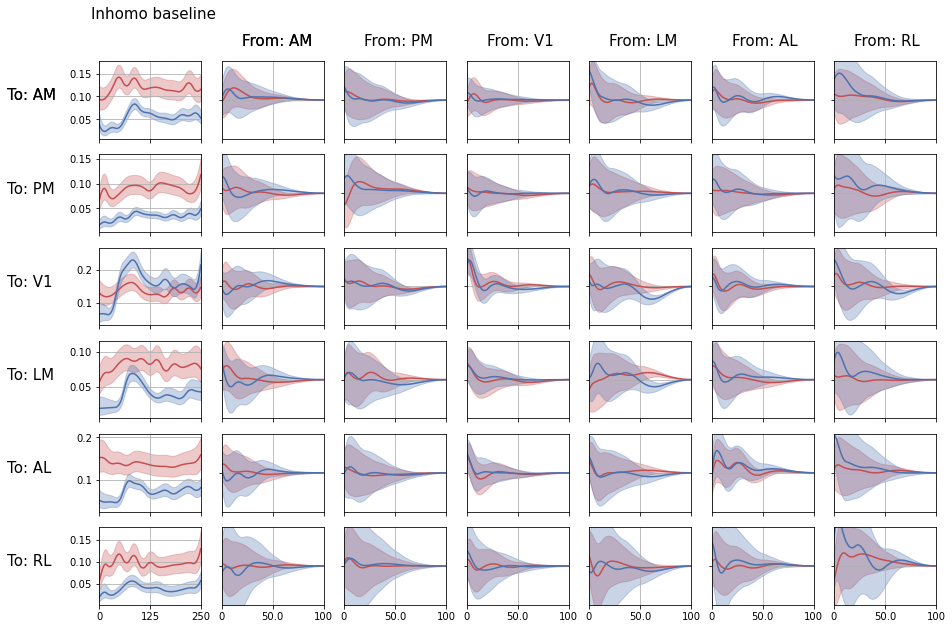

In [23]:
# Plot filters
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize=15
filter_length = 100
filter_amp = 0.2
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length], 
                       [0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.2*filter_length, 1.35*filter_amp, f'Inhomo baseline', fontsize=fontsize)


# Get effect's output

## Fit

In [24]:
num_basis_baseline = 15
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_output(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_output(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

## Figure (plot the filter outputs)

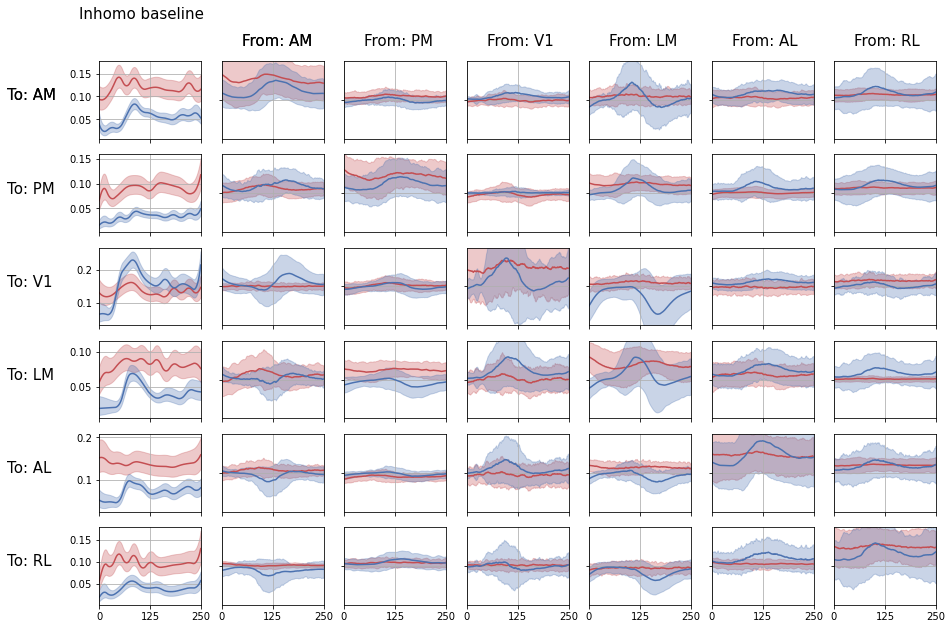

In [25]:
# Plot filters
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize=15
filter_length = V1.nt
filter_amp = 1
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.2*filter_length, 0.27*filter_amp, f'Inhomo baseline', fontsize=fontsize)

# Plot graph

In [26]:
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
angle_list = [90, 65, 0, -90, -135, 165, 115]
dis_from_center = [1, 1, 0.5 ,1 ,1, 0.8, 1]

import networkx as nx
G = nx.DiGraph()
G.add_nodes_from([ name for name in name_dict.values() ])
pos_standard = {}
for i, angle in enumerate(angle_list):
    dis = dis_from_center[i]
    pos_standard[name_dict[i-1]] = dis*np.array([np.cos(angle/360*2*np.pi), 
                                                 np.sin(angle/360*2*np.pi)])

In [36]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.0, 0.25]
auto_pick = 1

probe_list = V1.selected_probes
running = {}
stationary = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    running[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    stationary[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary[i,j] = filter_list[k]
        k += 1


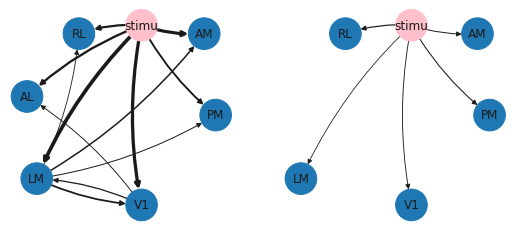

In [42]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.05
plot_amp = 15

import networkx as nx

plt.subplots(figsize=(9,4))
plt.subplot(1,2,1)
to_plot_result = stationary
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)